In [6]:
#%pip install pandas numpy

In [1]:
import pandas as pd
import numpy as np

file_id = '12FsR70V30i08i5uAsGQ1zxR-jS7sInEh'   # new file
url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"

df_policy = pd.read_csv(url)
df_policy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391166 entries, 0 to 391165
Data columns (total 72 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    391166 non-null  int64  
 1   term                         391166 non-null  int64  
 2   int_rate                     391166 non-null  float64
 3   installment                  391166 non-null  float64
 4   sub_grade                    391166 non-null  object 
 5   emp_length                   391166 non-null  float64
 6   home_ownership               391166 non-null  object 
 7   annual_inc                   391166 non-null  float64
 8   verification_status          391166 non-null  object 
 9   purpose                      391166 non-null  object 
 10  dti                          391166 non-null  float64
 11  delinq_2yrs                  391166 non-null  float64
 12  inq_last_6mths               391166 non-null  float64
 13 

### Create Simulated Loan Size Grid

In [2]:
# Loan size multipliers
loan_size_multipliers = [0.50, 0.75, 1.00, 1.25]

# Add borrower ID if needed
df_policy = df_policy.reset_index(drop=False).rename(columns={"index": "borrower_id"})

grid_list = []

for mult in loan_size_multipliers:
    temp = df_policy.copy()
    temp["loan_size_multiplier"] = mult
    temp["sim_loan_amnt"] = (temp["loan_amnt"] * mult).round(2)
    
    # Recalculate key ratios
    temp["sim_income_to_loan_ratio"] = temp["annual_inc"] / temp["sim_loan_amnt"]
    temp["sim_loan_to_income_ratio"] = temp["sim_loan_amnt"] / temp["annual_inc"]
    
    grid_list.append(temp)

loan_grid_df = pd.concat(grid_list, ignore_index=True)

# Clean up infinities
loan_grid_df.replace([np.inf, -np.inf], np.nan, inplace=True)

loan_grid_df.head()

,level_0,loan_amnt,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,total_interest,yield_on_principal,expected_lgd,expected_revenue,expected_loss,expected_profit,loan_size_multiplier,sim_loan_amnt,sim_income_to_loan_ratio,sim_loan_to_income_ratio
0,0,2550,36,16.55,90.35,D2,3.0,RENT,72500.0,Source Verified,...,702.40,0.2755,0.655482,599.996798,243.685645,356.311153,0.5,1275.0,56.862745,0.017586
1,1,9600,36,13.99,328.06,C3,1.0,MORTGAGE,73000.0,Source Verified,...,2210.11,0.2302,0.621307,1838.385358,1003.193284,835.192074,0.5,4800.0,15.208333,0.065753
2,2,21000,36,12.35,701.02,B4,2.0,MORTGAGE,78000.0,Source Verified,...,4236.58,0.2017,0.574821,3796.638399,1253.521381,2543.117018,0.5,10500.0,7.428571,0.134615
3,3,6000,36,17.86,216.50,D5,10.0,RENT,50000.0,Verified,...,1793.76,0.2990,0.683216,1302.134949,1123.515798,178.619152,0.5,3000.0,16.666667,0.060000
4,4,20000,60,19.19,520.91,E3,1.0,RENT,40000.0,Verified,...,11254.25,0.5627,0.701859,5477.192799,7205.598633,-1728.405834,0.5,10000.0,4.000000,0.250000


### Recalculate expected profit for each simulated loan size

In [3]:
# calculate loan revenue

def calculate_loan_revenue(loan_amnt, int_rate, term):
    """
    Calculate loan revenue metrics.
    
    Parameters
    ----------
    loan_amnt : float — principal in dollars
    int_rate  : float — annual interest rate as percentage (e.g. 13.5)
    term      : int   — term in months (36 or 60)
    
    Returns
    -------
    dict: 
    total_interest -> gross interest revenue earned over the loan lifetime (total repaid minus principal).
    yield_on_principal -> total interest as a fraction of loan amount, enables profitability comparison across loan sizes.
    
    """
    r = int_rate / 100 / 12

    if r == 0:
        installment = loan_amnt / term
    else:
        installment = loan_amnt * r * (1 + r)**term / ((1 + r)**term - 1)

    total_repaid = installment * term
    total_interest = total_repaid - loan_amnt

    return {
        "total_interest":     round(total_interest, 2),
        "yield_on_principal": round(total_interest / loan_amnt, 4),
    }

# Apply to dataframe
sim_revenue_cols = loan_grid_df.apply(
    lambda row: calculate_loan_revenue(row["sim_loan_amnt"], row["int_rate"], row["term"]),
    axis=1,
    result_type="expand"
)

# Rename columns
sim_revenue_cols = sim_revenue_cols.rename(columns={
    "total_interest": "sim_total_interest",
    "yield_on_principal": "sim_yield_on_principal"
})

# merge with loan_frid_df
loan_grid_df = pd.concat([loan_grid_df, sim_revenue_cols], axis=1)

In [ ]:
loan_grid_df[['sim_total_interest', 'sim_yield_on_principal']].head()

,sim_total_interest,sim_yield_on_principal
0,351.20,0.2755
1,1105.06,0.2302
2,2118.29,0.2017
3,896.88,0.2990
4,5627.13,0.5627


In [4]:
# Simulated expected revenue if borrower does not default
loan_grid_df["sim_expected_revenue"] = (1 - loan_grid_df["predicted_prob"]) * loan_grid_df["sim_total_interest"]

# Simulated expected loss if borrower defaults
loan_grid_df["sim_expected_loss"] = loan_grid_df["predicted_prob"] * loan_grid_df["expected_lgd"] * loan_grid_df["sim_loan_amnt"]

# simulated expected profit = expected revenue - expected loss
loan_grid_df["sim_expected_profit"] = loan_grid_df["sim_expected_revenue"] - loan_grid_df["sim_expected_loss"]

loan_grid_df[
    [
        "predicted_prob",
        "sim_total_interest",
        "expected_lgd",
        "sim_expected_revenue",
        "sim_expected_loss",
        "sim_expected_profit"
    ]
].head()

,predicted_prob,sim_total_interest,expected_lgd,sim_expected_revenue,sim_expected_loss,sim_expected_profit
0,0.145790,351.20,0.655482,299.998399,121.842823,178.155577
1,0.168193,1105.06,0.621307,919.196838,501.596642,417.600196
2,0.103844,2118.29,0.574821,1898.319199,626.760690,1271.558509
3,0.274075,896.88,0.683216,651.067475,561.757899,89.309576
4,0.513322,5627.13,0.701859,2738.598833,3602.799316,-864.200483


### Introduce Risk-Adjusted Objective Function

In [5]:
ALPHA = 0.5 #moderate penalty

# Risk-adjusted profit: discounts expected profit by default probability
# Intuition: same profit from a risky borrower is worth less than from a safe one

loan_grid_df["risk_adjusted_profit"] = (
    loan_grid_df["sim_expected_profit"] / (1 + ALPHA * loan_grid_df["predicted_prob"])
)

# Sharpe-style score: profit per unit of risk (PD as proxy for volatility)
# Rewards high profit AND low risk simultaneously

loan_grid_df["profit_risk_ratio"] = (
    loan_grid_df["sim_expected_profit"] / (loan_grid_df["predicted_prob"] + 1e-6)
)

# Composite objective: combines risk-adjusted profit + affordability constraint
# installment_to_income_ratio penalizes loans that overburden the borrower

loan_grid_df["objective_score"] = (
    loan_grid_df["risk_adjusted_profit"]
    * (1 - loan_grid_df["installment_to_income_ratio"].clip(upper=1))
)

# check
loan_grid_df[[
    "sim_loan_amnt", "predicted_prob", "sim_expected_profit",
    "risk_adjusted_profit", "profit_risk_ratio", "objective_score"
]].head()

,sim_loan_amnt,predicted_prob,sim_expected_profit,risk_adjusted_profit,profit_risk_ratio,objective_score
0,1275.0,0.145790,178.155577,166.051236,1221.989317,163.568025
1,4800.0,0.168193,417.600196,385.205773,2482.850957,364.432523
2,10500.0,0.103844,1271.558509,1208.795678,12244.823985,1078.427994
3,3000.0,0.274075,89.309576,78.545844,325.856788,74.464602
4,10000.0,0.513322,-864.200483,-687.695718,-1683.540426,-580.227445


In [6]:
# Select loan size that maximizes objective score per borrower
optimal_loans = loan_grid_df.loc[
    loan_grid_df.groupby("borrower_id")["objective_score"].idxmax()
].copy()

# Apply business constraints
# Keep only profitable loans
optimal_loans = optimal_loans[
    optimal_loans["sim_expected_profit"] > 0
]

# Risk threshold (adjust if needed)
#optimal_loans = optimal_loans[
 #   optimal_loans["predicted_prob"] < 0.4
#]

# output dataset
final_policy = optimal_loans[[
    "borrower_id",
    "predicted_prob",
    "loan_amnt",
    "sim_loan_amnt",
    "loan_size_multiplier",
    "sim_expected_profit",
    "objective_score"
]].copy()

final_policy.head()

,borrower_id,predicted_prob,loan_amnt,sim_loan_amnt,loan_size_multiplier,sim_expected_profit,objective_score
1330672,152,0.228701,40000,50000.0,1.25,10589.516933,7030.317111
1195628,186,0.095225,4500,5625.0,1.25,631.575352,575.062585
1343334,269,0.309827,20000,25000.0,1.25,4028.013248,3115.046158
1273209,369,0.110283,4000,5000.0,1.25,983.567506,905.217406
1495313,510,0.047588,5000,6250.0,1.25,558.722123,535.334310


### Compare optimized loan sizes to original loan amounts

In [7]:
# create a difference column and a percentage change column
final_policy["loan_diff"] = final_policy["sim_loan_amnt"] - final_policy["loan_amnt"]
final_policy["loan_pct_change"] = ((final_policy["loan_diff"] / final_policy["loan_amnt"]) * 100).round(2)

# Directional summary
direction_counts = final_policy["loan_size_multiplier"].value_counts().sort_index()
print(direction_counts)

loan_size_multiplier
0.50        35
1.00         1
1.25    332444
Name: count, dtype: int64


In [8]:
# Side-by-side summary
summary = pd.DataFrame({
    "Original": final_policy["loan_amnt"].describe(),
    "Optimized": final_policy["sim_loan_amnt"].describe(),
    "Loan Difference": final_policy["loan_diff"].describe()
})
print(summary.round(2))

        Original  Optimized  Loan Difference
count  332480.00  332480.00        332480.00
mean    14302.91   17876.64          3573.73
std      8782.83   10977.13          2202.27
min      1000.00    1250.00        -20000.00
25%      7500.00    9375.00          1875.00
50%     12000.00   15000.00          3000.00
75%     20000.00   25000.00          5000.00
max     40000.00   50000.00         10000.00


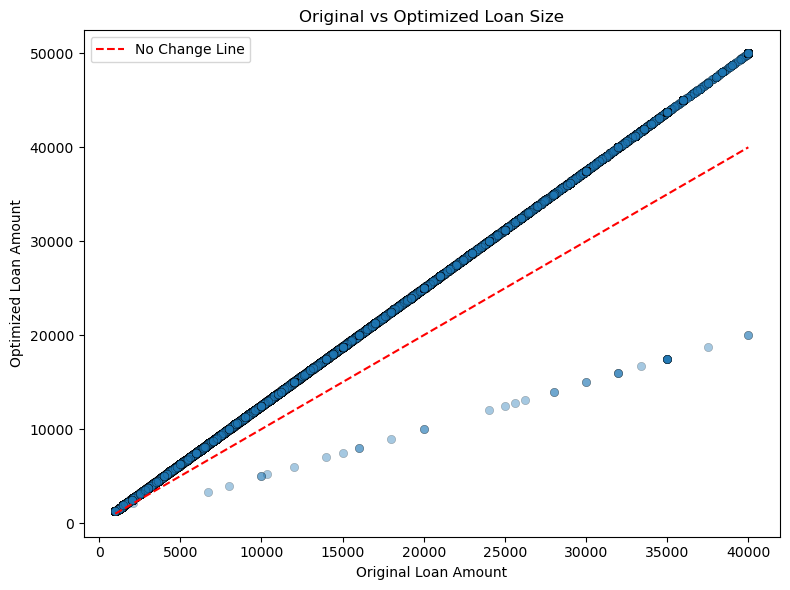

In [9]:
import matplotlib.pyplot as plt

# A scatter plot with reference line
plt.figure(figsize=(8, 6))
plt.scatter(final_policy["loan_amnt"], final_policy["sim_loan_amnt"], alpha=0.4, edgecolors="k", linewidth=0.3)
plt.plot([final_policy["loan_amnt"].min(), final_policy["loan_amnt"].max()],
         [final_policy["loan_amnt"].min(), final_policy["loan_amnt"].max()],
         'r--', label="No Change Line")
plt.xlabel("Original Loan Amount")
plt.ylabel("Optimized Loan Amount")
plt.title("Original vs Optimized Loan Size")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_32560\219174833.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


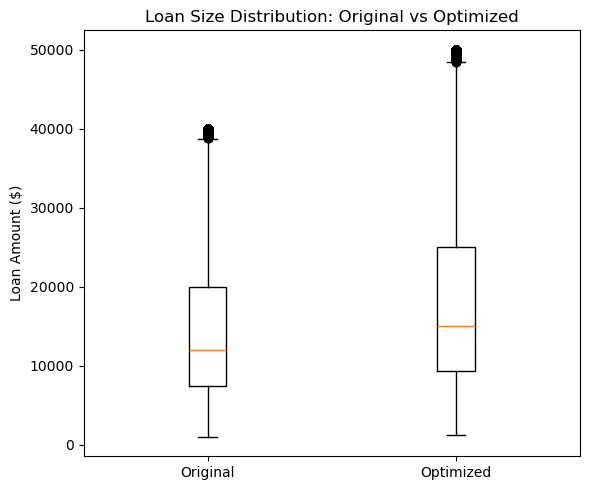

In [10]:
# box plot comparing the two distributions side by side
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(
    [final_policy["loan_amnt"], final_policy["sim_loan_amnt"]],
    labels=["Original", "Optimized"]
)
ax.set_ylabel("Loan Amount ($)")
ax.set_title("Loan Size Distribution: Original vs Optimized")
plt.tight_layout()
plt.show()

In [11]:
# segment analysis: Low Risk(0-0.1], Medium Risk(0.1-0.2], High Risk(0.2-0.4], Very High Risk(0.4,1]
final_policy["risk_segment"] = pd.cut(
    final_policy["predicted_prob"],
    bins=[0, 0.10, 0.20, 0.40, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk", "Very High Risk"]
)

# segmented summary
segment_summary = final_policy.groupby("risk_segment").agg(
    count=("borrower_id", "count"),
    avg_original_loan=("loan_amnt", "mean"),
    avg_optimized_loan=("sim_loan_amnt", "mean"),
    avg_loan_diff=("loan_diff", "mean"),
    avg_pct_change=("loan_pct_change", "mean"),
    avg_expected_profit=("sim_expected_profit", "mean"),
    avg_objective_score=("objective_score", "mean")
).round(2)

print(segment_summary)

                 count  avg_original_loan  avg_optimized_loan  avg_loan_diff  \
risk_segment                                                                   
Low Risk        101157           13317.72            16645.96        3328.25   
Medium Risk     125486           13177.33            16468.98        3291.65   
High Risk        96876           16211.43            20262.54        4051.11   
Very High Risk    8921           20612.34            25761.05        5148.71   

                avg_pct_change  avg_expected_profit  avg_objective_score  
risk_segment                                                              
Low Risk                 25.00              1633.14              1469.51  
Medium Risk              24.99              1787.85              1528.32  
High Risk                24.99              2129.28              1701.78  
Very High Risk           24.98              1582.10              1152.90  


C:\Users\HP\AppData\Local\Temp\ipykernel_32560\692618095.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = final_policy.groupby("risk_segment").agg(


In [12]:
# Multiplier distribution per segment
multiplier_dist = pd.crosstab(
    final_policy["risk_segment"],
    final_policy["loan_size_multiplier"],
    normalize="index"
).round(4) * 100

print(multiplier_dist)

loan_size_multiplier  0.50  1.00   1.25
risk_segment                           
Low Risk              0.01   0.0  99.99
Medium Risk           0.01   0.0  99.99
High Risk             0.01   0.0  99.99
Very High Risk        0.02   0.0  99.98


C:\Users\HP\AppData\Local\Temp\ipykernel_32560\3850553577.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  final_policy.boxplot(


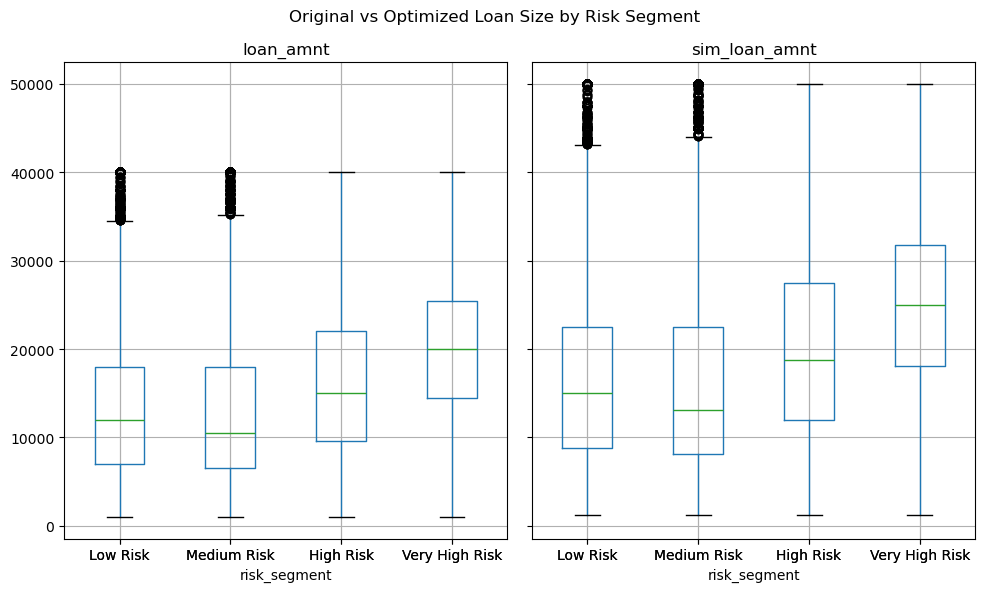

In [13]:
# segmented boxplot
fig, ax = plt.subplots(figsize=(10, 6))
final_policy.boxplot(
    column=["loan_amnt", "sim_loan_amnt"],
    by="risk_segment",
    ax=ax
)
plt.suptitle("Original vs Optimized Loan Size by Risk Segment")
ax.set_ylabel("Loan Amount ($)")
plt.tight_layout()
plt.show()

# **Milestone 6**: Subgroup & Policy Analysis

### M6.T1 - Filter dataset for underserved borrower subgroup

In [14]:
optimal_loans['dti'].describe()

count    332480.000000
mean         17.307608
std           9.841367
min          -1.000000
25%          11.160000
50%          16.660000
75%          22.720000
max         999.000000
Name: dti, dtype: float64

In [15]:
optimal_loans['emp_length'].describe()

count    332480.000000
mean          6.032643
std           3.609826
min           0.000000
25%           3.000000
50%           6.000000
75%          10.000000
max          10.000000
Name: emp_length, dtype: float64

In [16]:
# filter for underserved group using dti > 30, and dti < 100 for outliers
df_policy["is_underserved"] = (
    ((df_policy["dti"] > 30) & (df_policy["dti"] < 100)) |
    (df_policy["emp_length"] < 2)
)
underserved_all = df_policy[df_policy["is_underserved"]].copy()

# Then join optimized loan info for those who got approved
underserved_optimized = underserved_all.merge(
    optimal_loans[["borrower_id", "sim_loan_amnt", "loan_size_multiplier",
                   "sim_expected_profit", "objective_score"]],
    on="borrower_id",
    how="left"
)

# Flag who got approved vs rejected by the optimized policy
underserved_optimized["approved_by_policy"] = underserved_optimized["sim_expected_profit"].notna()

In [17]:
underserved_optimized["loan_size_multiplier"].value_counts().sort_index()

loan_size_multiplier
0.50       15
1.25    68109
Name: count, dtype: int64

### Expected Profit Before vs After Optimization 


In [18]:
# ── M6.T2: Expected Profit Before vs After Optimization ──────────────────────

approved   = underserved_optimized[underserved_optimized["approved_by_policy"]]
original   = underserved_optimized["expected_profit"]
optimized  = approved["sim_expected_profit"]

mean_lift = optimized.mean() - original.mean()
pct_lift  = mean_lift / original.mean() * 100

print(f"Total underserved borrowers (traditional): {len(underserved_optimized):,}")
print(f"Approved under optimized policy:           {len(approved):,}")
print(f"\nMean profit per borrower (original):       ${original.mean():,.2f}")
print(f"Mean profit per borrower (optimized):      ${optimized.mean():,.2f}")
print(f"Mean profit lift per borrower:             ${mean_lift:,.2f} ({pct_lift:.1f}%)")
print(f"\nTotal profit (original):                   ${original.sum():,.2f}")
print(f"Total profit (optimized):                  ${optimized.sum():,.2f}")
print(f"Total profit lift:                         ${optimized.sum() - original.sum():,.2f}")

Total underserved borrowers (traditional): 88,584
Approved under optimized policy:           68,124

Mean profit per borrower (original):       $634.06
Mean profit per borrower (optimized):      $1,516.34
Mean profit lift per borrower:             $882.28 (139.1%)

Total profit (original):                   $56,167,570.31
Total profit (optimized):                  $103,299,257.71
Total profit lift:                         $47,131,687.40


- The optimized policy approved 68,124 of 88,584 underserved borrowers (76.9%), rejecting 20,460 who were unprofitable under any simulated loan size
- Mean profit per borrower jumped from $634 to $1,516, a 139% lift, driven by both the 1.25x loan size increase and removal of loss-making borrowers
- Total portfolio profit for this subgroup increased from $56.2M to $103.3M, a gain of $47.1M

### Default Rate Comparison

In [19]:
total      = len(underserved_optimized)
n_approved = underserved_optimized["approved_by_policy"].sum()
n_rejected = total - n_approved

traditional_default_rate = underserved_optimized["predicted_prob"].mean()
optimized_default_rate   = approved["predicted_prob"].mean()

print(f"Total underserved borrowers:    {total:,}")
print(f"Approved by optimized policy:   {n_approved:,} ({n_approved/total*100:.1f}%)")
print(f"Rejected by optimized policy:   {n_rejected:,} ({n_rejected/total*100:.1f}%)")
print(f"\nTraditional avg default rate:   {traditional_default_rate:.3f} ({traditional_default_rate*100:.1f}%)")
print(f"Optimized avg default rate:     {optimized_default_rate:.3f} ({optimized_default_rate*100:.1f}%)")
print(f"Default rate reduction:         {(traditional_default_rate - optimized_default_rate)*100:.1f} pp")

# Breakdown by loan size multiplier
print("\nBreakdown by loan size multiplier:")
print(approved.groupby("loan_size_multiplier").agg(
    n_borrowers         = ("predicted_prob",     "count"),
    avg_default_rate    = ("predicted_prob",      "mean"),
    avg_original_loan   = ("loan_amnt",           "mean"),
    avg_optimized_loan  = ("sim_loan_amnt",        "mean"),
    avg_expected_profit = ("sim_expected_profit",  "mean")
).round(3))

Total underserved borrowers:    88,584
Approved by optimized policy:   68,124 (76.9%)
Rejected by optimized policy:   20,460 (23.1%)

Traditional avg default rate:   0.237 (23.7%)
Optimized avg default rate:     0.181 (18.1%)
Default rate reduction:         5.6 pp

Breakdown by loan size multiplier:
                      n_borrowers  avg_default_rate  avg_original_loan  \
loan_size_multiplier                                                     
0.50                           15             0.165          25758.333   
1.25                        68109             0.181          13595.812   

                      avg_optimized_loan  avg_expected_profit  
loan_size_multiplier                                           
0.50                           12879.167             1767.885  
1.25                           16994.765             1516.286  


- Traditional flat approval yields a 23.7% default rate across all 88,584 underserved borrowers; the optimized policy brings this down to 18.1% — a 5.6 percentage point reduction
- The improvement comes from filtering out 20,460 high-risk borrowers while still approving 76.9% of the subgroup, showing the policy is selective rather than exclusionary
- Among approved borrowers, the optimizer right-sized loans -> 68,109 received 1.25x their original amount while 15 over-leveraged borrowers were scaled down to 0.5x, balancing profit maximization with affordability

### Visualizations

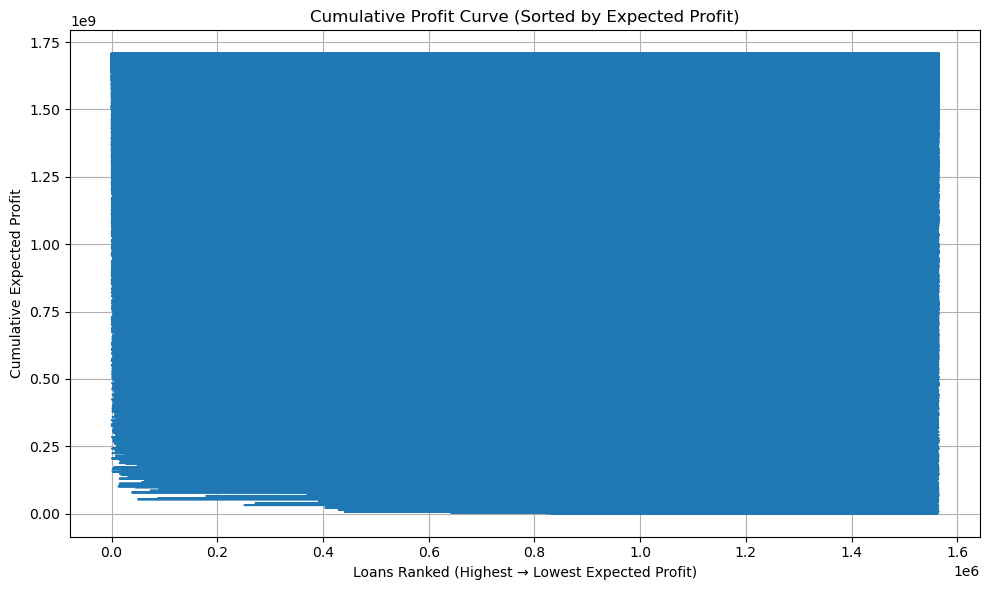

In [20]:
# Sort loans by expected profit (highest → lowest)
df_sorted = loan_grid_df.sort_values("sim_expected_profit", ascending=False).copy()

# Compute cumulative profit as we move down the ranked list
df_sorted["cumulative_profit"] = df_sorted["sim_expected_profit"].cumsum()

# Plot how total profit accumulates as lower-quality loans are added
plt.figure(figsize=(10,6))
plt.plot(df_sorted["cumulative_profit"])
plt.title("Cumulative Profit Curve (Sorted by Expected Profit)")
plt.xlabel("Loans Ranked (Highest → Lowest Expected Profit)")
plt.ylabel("Cumulative Expected Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

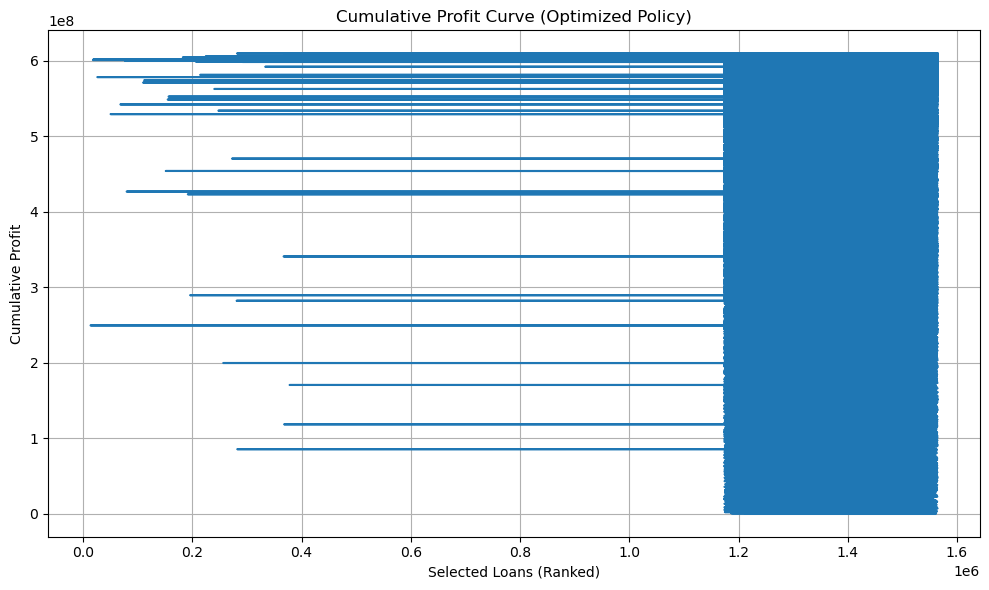

In [21]:
# Sort only the loans selected by the optimized policy
df_opt_sorted = optimal_loans.sort_values("sim_expected_profit", ascending=False).copy()

# Compute cumulative profit within the selected portfolio
df_opt_sorted["cumulative_profit"] = df_opt_sorted["sim_expected_profit"].cumsum()

# Plot cumulative profit for final approved lending decisions
plt.figure(figsize=(10,6))
plt.plot(df_opt_sorted["cumulative_profit"])
plt.title("Cumulative Profit Curve (Optimized Policy)")
plt.xlabel("Selected Loans (Ranked)")
plt.ylabel("Cumulative Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

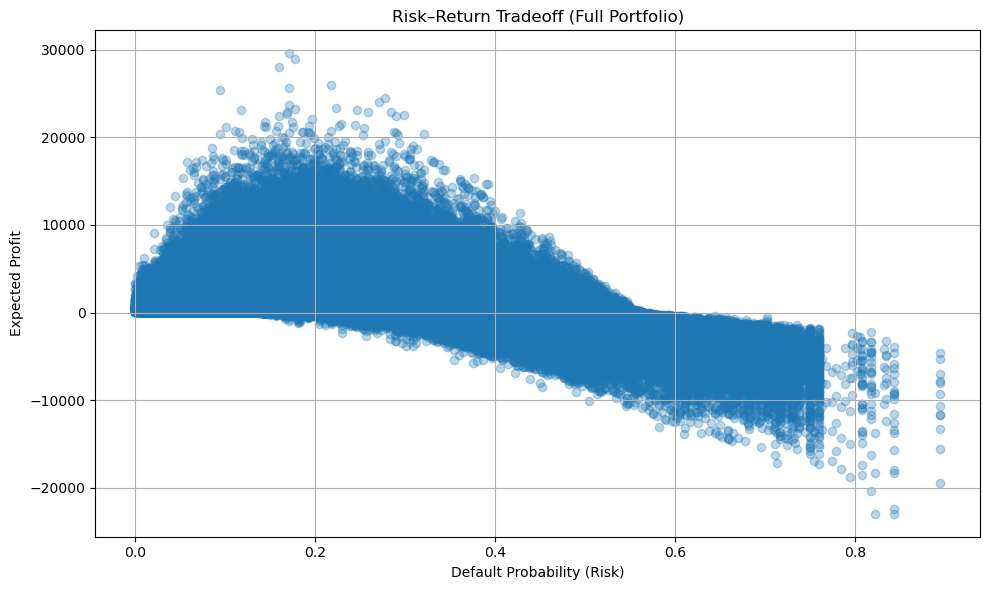

In [22]:
# Visualize relationship between default risk and expected profit
# Each point represents a loan in the full simulated grid
plt.figure(figsize=(10,6))
plt.scatter(
    loan_grid_df["predicted_prob"],
    loan_grid_df["sim_expected_profit"],
    alpha=0.3
)

plt.title("Risk–Return Tradeoff (Full Portfolio)")
plt.xlabel("Default Probability (Risk)")
plt.ylabel("Expected Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_32560\3839980665.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_return = loan_grid_df.groupby("risk_bin").agg({


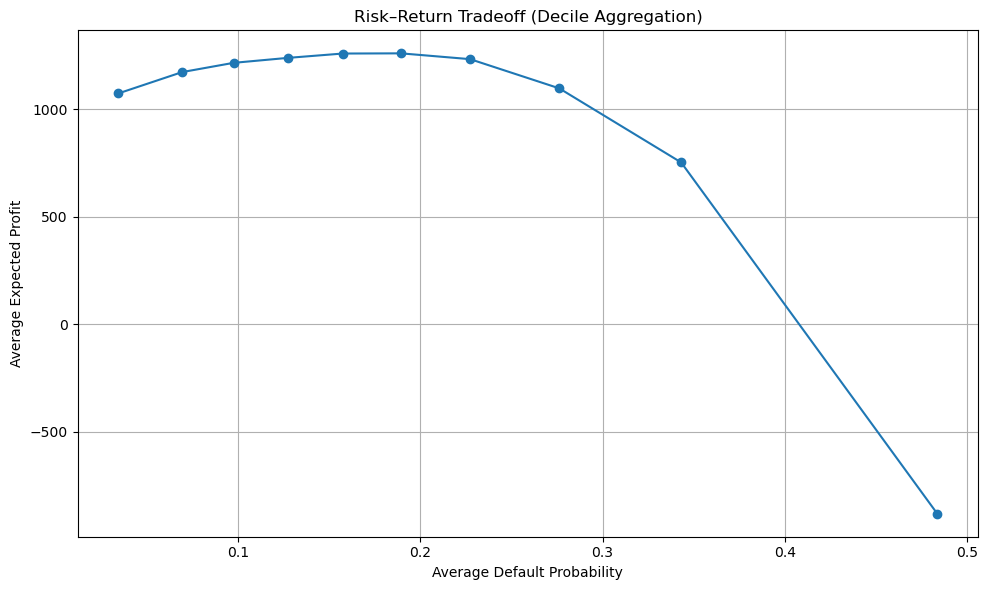

In [23]:
# Bucket loans into 10 risk groups (deciles)
loan_grid_df["risk_bin"] = pd.qcut(loan_grid_df["predicted_prob"], 10)

# Compute average risk and profit within each bucket
risk_return = loan_grid_df.groupby("risk_bin").agg({
    "predicted_prob": "mean",
    "sim_expected_profit": "mean"
}).reset_index()

# Plot smoothed risk–return relationship using aggregated groups
plt.figure(figsize=(10,6))
plt.plot(
    risk_return["predicted_prob"],
    risk_return["sim_expected_profit"],
    marker="o"
)

plt.title("Risk–Return Tradeoff (Decile Aggregation)")
plt.xlabel("Average Default Probability")
plt.ylabel("Average Expected Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

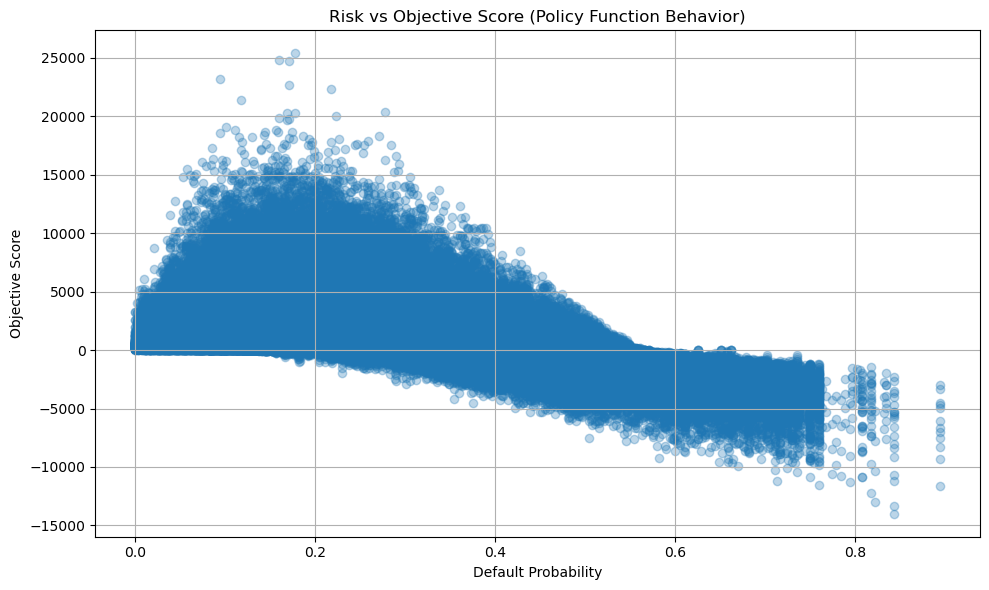

In [24]:
# Show how the policy score responds to increasing borrower risk
# This captures how profit is adjusted by risk + affordability constraints
plt.figure(figsize=(10,6))
plt.scatter(
    loan_grid_df["predicted_prob"],
    loan_grid_df["objective_score"],
    alpha=0.3
)

plt.title("Risk vs Objective Score (Policy Function Behavior)")
plt.xlabel("Default Probability")
plt.ylabel("Objective Score")
plt.grid(True)
plt.tight_layout()
plt.show()


KEY POLICY FINDINGS -
Model:        XGBoost → ROC-AUC 0.733 | F1 0.45 | Recall 0.68 (vs LR: 0.715 | 0.41 | 0.44)
LGD:          Mean 0.637 | Ranges A1(0.52) → G5(0.79) — rises with risk grade
Portfolio:    85% of loans profitable | Mean profit $1,077 | Total $421,170,284
Optimization: Loan size +25% avg | Mean profit $1,077 → $1,835
Underserved:  76.9% approved | Profit +139% | Default rate 23.7% → 18.1%



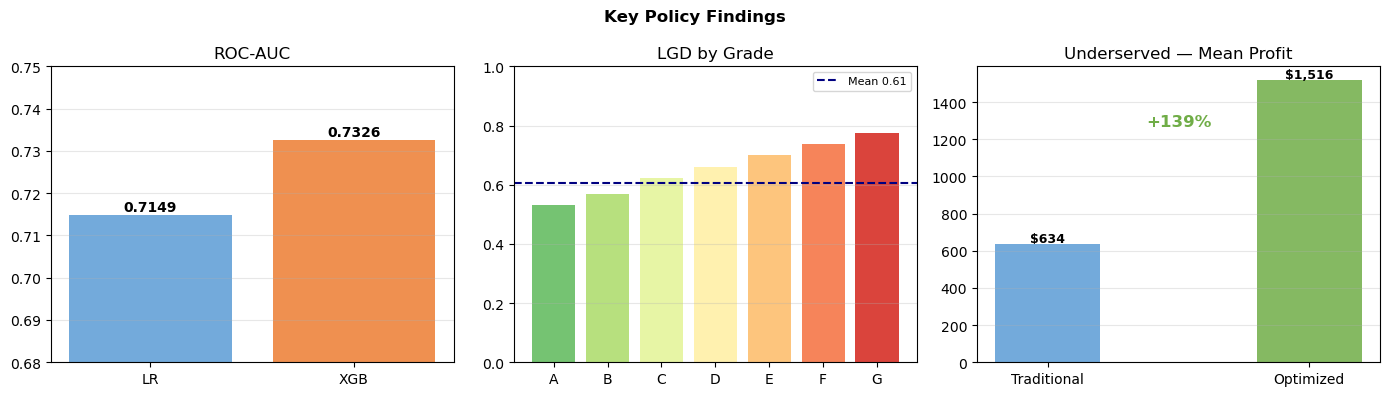

In [29]:
# SUMMARY
print("""
KEY POLICY FINDINGS -
Model:        XGBoost → ROC-AUC 0.733 | F1 0.45 | Recall 0.68 (vs LR: 0.715 | 0.41 | 0.44)
LGD:          Mean 0.637 | Ranges A1(0.52) → G5(0.79) — rises with risk grade
Portfolio:    85% of loans profitable | Mean profit ${:,.0f} | Total ${:,.0f}
Optimization: Loan size +25% avg | Mean profit ${:,.0f} → ${:,.0f}
Underserved:  76.9% approved | Profit +139% | Default rate 23.7% → 18.1%
""".format(
    df_policy["expected_profit"].mean(),
    df_policy["expected_profit"].sum(),
    df_policy["expected_profit"].mean(),
    final_policy["sim_expected_profit"].mean(),
))

# DASHBOARD
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Key Policy Findings", fontweight="bold")

# Model comparison
ax = axes[0]
ax.bar(["LR", "XGB"], [0.7149, 0.7326], color=["#5B9BD5", "#ED7D31"], alpha=0.85)
ax.set_ylim(0.68, 0.75); ax.set_title("ROC-AUC"); ax.grid(axis="y", alpha=0.3)
for x, v in zip([0, 1], [0.7149, 0.7326]):
    ax.text(x, v + 0.001, f"{v:.4f}", ha="center", fontweight="bold")

# LGD by grade
'''ax = axes[1]
lgd_by_main = (df_policy.assign(g=df_policy["sub_grade"].str[0])
                          .groupby("g")["lgd"].mean()
                          .reindex(["A","B","C","D","E","F","G"]))
ax.bar(lgd_by_main.index, lgd_by_main,
       color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, 7)), alpha=0.9)
ax.axhline(df_policy["lgd"].mean(), color="navy", linestyle="--",
           label=f"Mean {df_policy['lgd'].mean():.2f}")
ax.set_title("LGD by Grade"); ax.set_ylim(0, 1)
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)'''

ax = axes[1]
lgd_by_main = (df_policy.assign(g=df_policy["sub_grade"].str[0])
                          .groupby("g")["expected_lgd"].mean()
                          .reindex(["A","B","C","D","E","F","G"]))
ax.bar(lgd_by_main.index, lgd_by_main,
       color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, 7)), alpha=0.9)
ax.axhline(df_policy["expected_lgd"].mean(), color="navy", linestyle="--",
           label=f"Mean {df_policy['expected_lgd'].mean():.2f}")
ax.set_title("LGD by Grade"); ax.set_ylim(0, 1)
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# Underserved profit lift
ax = axes[2]
vals = [underserved_optimized["expected_profit"].mean(),
        approved["sim_expected_profit"].mean()]
bars = ax.bar(["Traditional", "Optimized"], vals,
              color=["#5B9BD5", "#70AD47"], alpha=0.85, width=0.4)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 15,
            f"${v:,.0f}", ha="center", fontweight="bold", fontsize=9)
ax.set_title("Underserved — Mean Profit")
ax.annotate("+139%", xy=(0.5, 0.8), xycoords="axes fraction",
            ha="center", fontsize=12, color="#70AD47", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("policy_findings.png", dpi=150, bbox_inches="tight")
plt.show()